# **MLIS Practical 09**

**Name:** Yesha Pandya  
**Enrollment No:** 23BT04175  
**Division:** A
**Batch**: C

## **Objective**
To implement a Hand Gesture Recognition Model using k-NN or CNN for classifying hand gestures.

## **Theoretical Overview**
Hand gesture recognition is a fundamental computer vision problem with applications in human-robot interaction, sign language translation, and touchless control systems.

Convolutional Neural Networks (CNNs) are uniquely suited for spatial feature extraction, automatically detecting hand contours, finger orientations, and joint configurations from raw pixel grids.

## **Mathematical Formulation**

#### 1. **2D Convolution Operation:**
For an input image $I$ and kernel filter $K$ of size $m \times n$, the output feature map $S(i,j)$ is computed as:
$$S(i, j) = (I * K)(i, j) = \sum_{m} \sum_{n} I(i - m, j - n) K(m, n) + b$$

#### 2. **Activation Function (ReLU):**
Introduces non-linearity to learn complex pathological representations:
$$f(x) = \max(0, x)$$

#### 3. **Max Pooling (Spatial Downsampling):**
Extracts the dominant feature activation within a sliding window $R$:
$$P(i, j) = \max_{(m, n) \in R} I(i + m, j + n)$$

#### 4. **Softmax Output Activation (Multi-Class Classification):**
For a gesture input with $K$ distinct classes (e.g., $K=24$ gesture signs), the probability for class $i$ is:
$$P(y = i \mid \mathbf{x}) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

#### 5. **Categorical Cross-Entropy Loss:**
$$\mathcal{L}_{CE} = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)$$

## **Step 1: Setup + Load dataset**

In [1]:
# Install kagglehub for direct dataset download in Google Colab
!pip install kagglehub -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import kagglehub

In [2]:
# Download Sign Language MNIST dataset directly via kagglehub
path = kagglehub.dataset_download("datamunge/sign-language-mnist")
print("Dataset downloaded to:", path)

# Load train and test CSV files
train_csv_path = os.path.join(path, "sign_mnist_train.csv")
test_csv_path  = os.path.join(path, "sign_mnist_test.csv")

df_train = pd.read_csv(train_csv_path)
df_test  = pd.read_csv(test_csv_path)

print(f"Training Data Shape: {df_train.shape}")
print(f"Testing Data Shape:  {df_test.shape}")

# Extract raw labels and pixel features (28x28 grayscale images)
y_train_raw = df_train['label'].values
X_train_raw = df_train.drop('label', axis=1).values.reshape(-1, 28, 28)

y_test_raw = df_test['label'].values
X_test_raw = df_test.drop('label', axis=1).values.reshape(-1, 28, 28)

# Map numeric labels (0-24, skipping 9='J' and 25='Z' due to motion requirements) to Alphabet Letters
gesture_classes = [chr(65 + i) for i in range(26) if i not in [9, 25]]
label_map = {idx: gesture_classes[i] for i, idx in enumerate(np.unique(y_train_raw))}

Using Colab cache for faster access to the 'sign-language-mnist' dataset.
Dataset downloaded to: /kaggle/input/sign-language-mnist
Training Data Shape: (27455, 785)
Testing Data Shape:  (7172, 785)


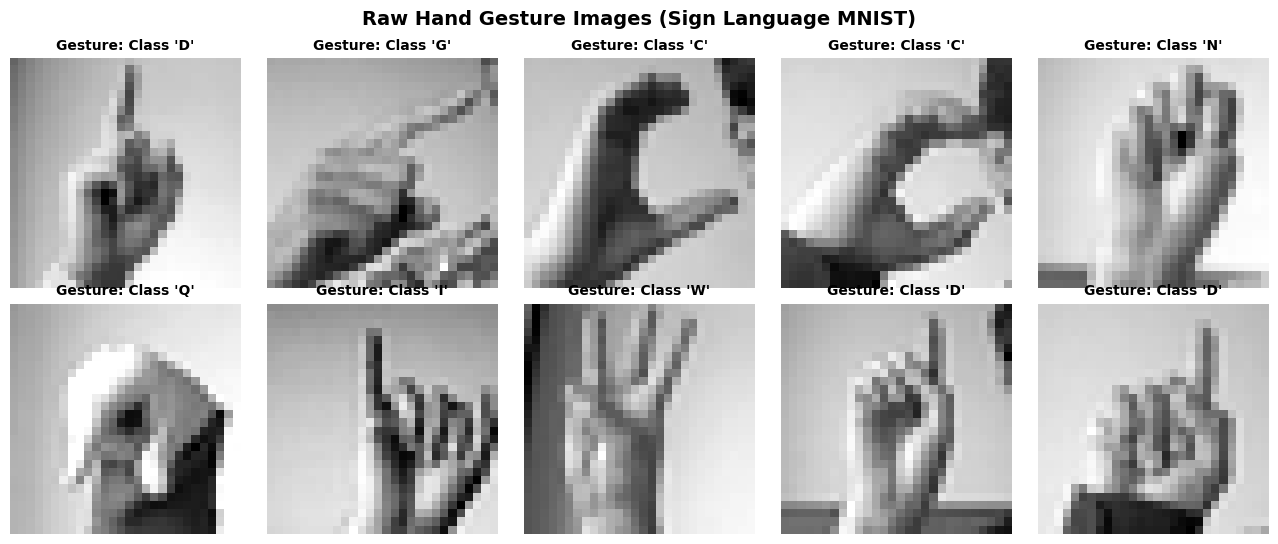

In [3]:
# Display raw hand gesture images loaded from dataset
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
fig.suptitle("Raw Hand Gesture Images (Sign Language MNIST)", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = X_train_raw[i]
    lbl = label_map.get(y_train_raw[i], str(y_train_raw[i]))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Gesture: Class '{lbl}'", fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## **Step 2: Image Preprocessing + Label Encoding**
Hand gesture images undergo the following preprocessing operations:
* **Pixel Normalization**: Rescaling pixel values from integer range $[0, 255]$ to floating-point range $[0.0, 1.0]$.
* **4D Tensor Reshaping**: Expanding dimensions to $(N, 28, 28, 1)$ to suit 2D CNN convolution operations.
* **One-Hot Label Encoding**: Converting categorical label indices into 24-dimensional binary target vectors.$$\mathbf{X}_{\text{norm}} = \frac{\mathbf{X}_{\text{raw}}}{255.0}$$

In [4]:
# 1. Normalize pixel values to range [0.0, 1.0]
X_train = (X_train_raw.astype('float32') / 255.0)[..., np.newaxis]
X_test  = (X_test_raw.astype('float32') / 255.0)[..., np.newaxis]

# 2. Re-index labels to contiguous range [0, 23] for 24 distinct classes
unique_labels = sorted(np.unique(y_train_raw))
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}

y_train_idx = np.array([label_to_index[lbl] for lbl in y_train_raw])
y_test_idx  = np.array([label_to_index[lbl] for lbl in y_test_raw])

# 3. Convert labels to one-hot encoded vectors
y_train_cat = tf.keras.utils.to_categorical(y_train_idx, num_classes=len(unique_labels))
y_test_cat  = tf.keras.utils.to_categorical(y_test_idx, num_classes=len(unique_labels))

print(f"Preprocessed X_train Shape: {X_train.shape} (Range: [{X_train.min():.1f}, {X_train.max():.1f}])")
print(f"Preprocessed X_test Shape:  {X_test.shape}  (Range: [{X_test.min():.1f}, {X_test.max():.1f}])")
print(f"One-Hot Target Matrix Shape: {y_train_cat.shape}")

Preprocessed X_train Shape: (27455, 28, 28, 1) (Range: [0.0, 1.0])
Preprocessed X_test Shape:  (7172, 28, 28, 1)  (Range: [0.0, 1.0])
One-Hot Target Matrix Shape: (27455, 24)


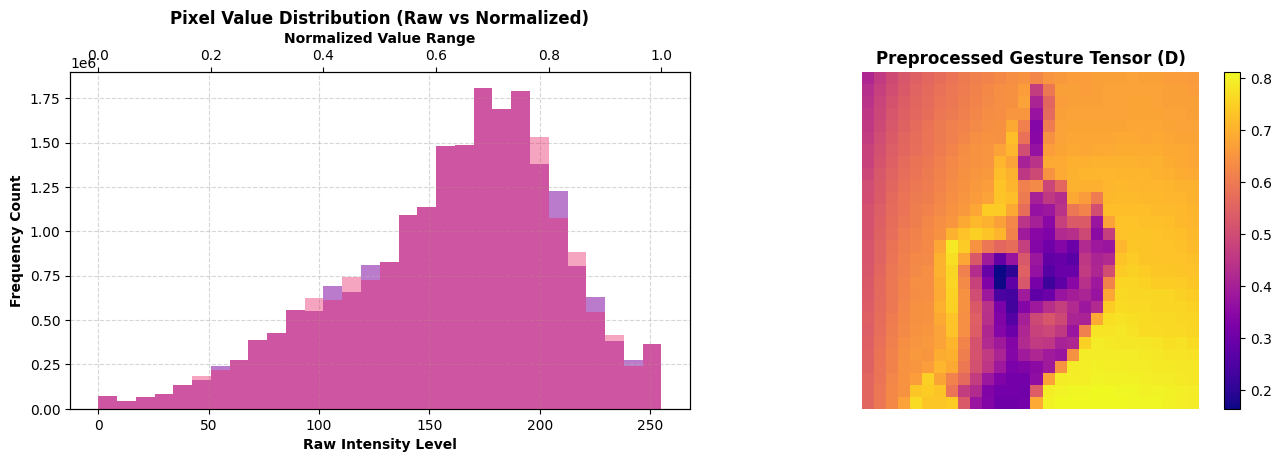

In [12]:
# Visualize preprocessing comparison (Histogram + Sample Image)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot pixel intensity distribution comparison
ax[0].hist(X_train_raw.ravel(), bins=30, color='#8E24AA', alpha=0.6, label='Raw Pixels [0, 255]')
ax[0].set_title("Pixel Value Distribution (Raw vs Normalized)", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Raw Intensity Level", fontweight='bold')
ax[0].set_ylabel("Frequency Count", fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.5)

ax_norm = ax[0].twiny()
ax_norm.hist(X_train.ravel(), bins=30, color='#E91E63', alpha=0.4, label='Normalized [0.0, 1.0]')
ax_norm.set_xlabel("Normalized Value Range", fontweight='bold')

# Show normalized preprocessed hand gesture sample
im = ax[1].imshow(X_train[0].squeeze(), cmap='plasma')
ax[1].set_title(f"Preprocessed Gesture Tensor ({label_map[y_train_raw[0]]})", fontsize=12, fontweight='bold')
ax[1].axis('off')
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## **Step 3: Dataset Partitioning + Class Distribution Analysis**
We evaluate the frequency distribution across all 24 hand gesture classes in the training and testing partitions.

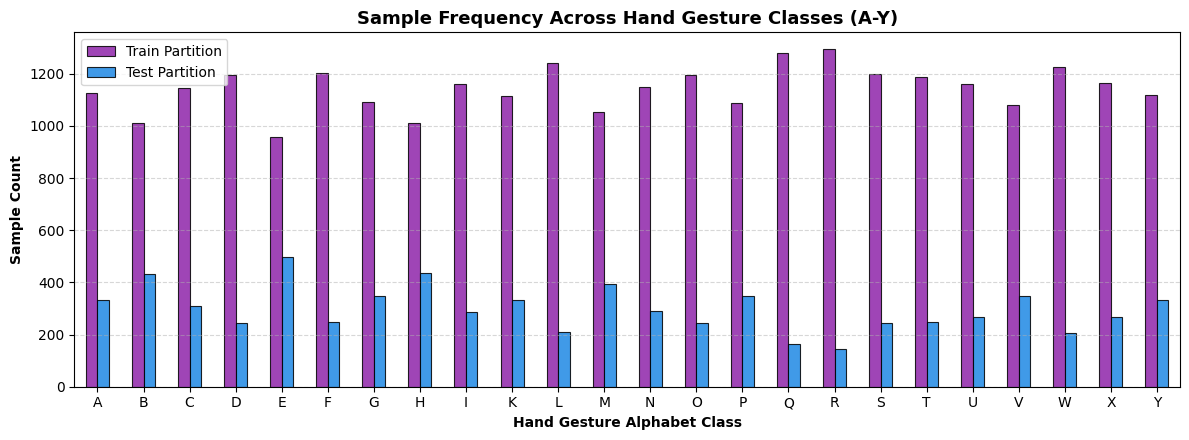

In [6]:
# Compute sample counts per gesture class
train_class_counts = pd.Series([gesture_classes[i] for i in y_train_idx]).value_counts().sort_index()
test_class_counts  = pd.Series([gesture_classes[i] for i in y_test_idx]).value_counts().sort_index()

df_class_dist = pd.DataFrame({
    'Train Partition': train_class_counts,
    'Test Partition': test_class_counts
})

# Gesture Class Sample Distribution Bar Chart
fig, ax = plt.subplots(figsize=(12, 4.5))
df_class_dist.plot(kind='bar', ax=ax, color=['#8E24AA', '#1E88E5'], edgecolor='black', linewidth=0.8, alpha=0.85)

plt.title("Sample Frequency Across Hand Gesture Classes (A-Y)", fontsize=13, fontweight='bold')
plt.xlabel("Hand Gesture Alphabet Class", fontweight='bold')
plt.ylabel("Sample Count", fontweight='bold')
plt.xticks(rotation=0)
plt.legend(frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Step 4: CNN Architecture Design for Gesture Recognition**
We build a multi-layer Convolutional Neural Network consisting of:
1. **Conv2D Layer 1**: 32 filters ($3 \times 3$), ReLU activation + BatchNormalization + MaxPooling ($2 \times 2$)
2. **Conv2D Layer 2**: 64 filters ($3 \times 3$), ReLU activation + BatchNormalization + MaxPooling ($2 \times 2$)
3. **Conv2D Layer 3**: 128 filters ($3 \times 3$), ReLU activation + MaxPooling ($2 \times 2$)
4. **Dense Classifier**: Flatten $\rightarrow$ 128 Dense Units $\rightarrow$ Dropout (0.30) $\rightarrow$ 24-unit Softmax Output Layer

In [7]:
# Build CNN model using Keras Sequential API
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Dense Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(unique_labels), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nCNN Network Architecture Summary:")
model.summary()


CNN Network Architecture Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,736 (952.09 KB)

 Trainable params: 243,544 (951.34 KB)

 Non-trainable params: 192 (768.00 B)

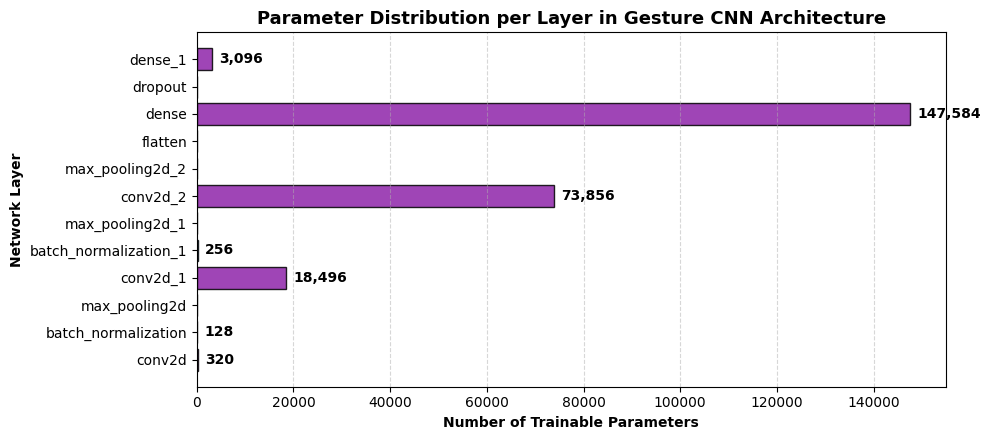

In [8]:
# Visualize Layer Parameter Profile Plot
layer_names = [layer.name for layer in model.layers]
layer_params = [layer.count_params() for layer in model.layers]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(layer_names, layer_params, color=['#8E24AA', '#1E88E5', '#E91E63', '#8E24AA', '#1E88E5', '#E91E63', '#8E24AA', '#1E88E5', '#E91E63', '#8E24AA', '#1E88E5'], edgecolor='black', alpha=0.85)

for bar in bars:
    width = bar.get_width()
    if width > 0:
        ax.text(width + max(layer_params)*0.01, bar.get_y() + bar.get_height()/2, f'{width:,}', ha='left', va='center', fontweight='bold')

plt.title("Parameter Distribution per Layer in Gesture CNN Architecture", fontsize=13, fontweight='bold')
plt.xlabel("Number of Trainable Parameters", fontweight='bold')
plt.ylabel("Network Layer", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Step 5: CNN Model Training**
Train the hand gesture recognition model for 12 epochs with a batch size of 64, utilizing a validation split of 15% from the training data.

Epoch 1/12
365/365 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.8320 - loss: 0.5630 - val_accuracy: 0.3571 - val_loss: 2.0471
Epoch 2/12
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9922 - loss: 0.0295 - val_accuracy: 0.9881 - val_loss: 0.0343
Epoch 3/12
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9952 - loss: 0.0175 - val_accuracy: 0.9917 - val_loss: 0.0259
Epoch 4/12
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9967 - loss: 0.0123 - val_accuracy: 1.0000 - val_loss: 4.1636e-04
Epoch 5/12
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9942 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 5.0744e-04
Epoch 6/12
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9960 - loss: 0.0117 - val_accuracy: 0.9934 - val_loss: 0.0187
Epoch 7/12
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9961 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 5.1038e-05
Epoch 8/12
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9979 - loss: 0.0071 - va

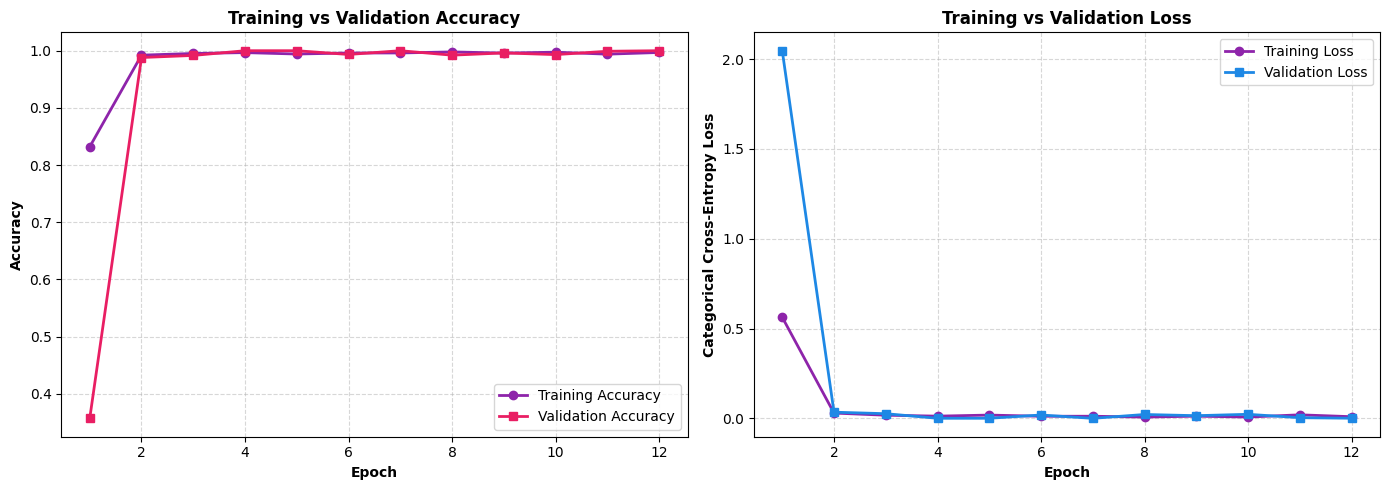

In [9]:
# Train CNN model
history = model.fit(
    X_train, y_train_cat,
    epochs=12,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

# Visualize Learning Curves (Accuracy + Loss Progression)
epochs_range = range(1, len(history.history['accuracy']) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Training vs Validation Accuracy
ax[0].plot(epochs_range, history.history['accuracy'], marker='o', color='#8E24AA', linewidth=2, label='Training Accuracy')
ax[0].plot(epochs_range, history.history['val_accuracy'], marker='s', color='#E91E63', linewidth=2, label='Validation Accuracy')
ax[0].set_title("Training vs Validation Accuracy", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Epoch", fontweight='bold')
ax[0].set_ylabel("Accuracy", fontweight='bold')
ax[0].legend(frameon=True)
ax[0].grid(True, linestyle='--', alpha=0.5)

# Plot Training vs Validation Loss
ax[1].plot(epochs_range, history.history['loss'], marker='o', color='#8E24AA', linewidth=2, label='Training Loss')
ax[1].plot(epochs_range, history.history['val_loss'], marker='s', color='#1E88E5', linewidth=2, label='Validation Loss')
ax[1].set_title("Training vs Validation Loss", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Epoch", fontweight='bold')
ax[1].set_ylabel("Categorical Cross-Entropy Loss", fontweight='bold')
ax[1].legend(frameon=True)
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## **Step 6: Testing and Multi-Class Metric Evaluation**
Evaluate the trained gesture recognition model on unseen test samples across accuracy, precision, recall, and F1-score.

In [10]:
# Generate predictions on unseen test dataset
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_idx = np.argmax(y_pred_probs, axis=1)

# Calculate quantitative evaluation metrics
test_acc = accuracy_score(y_test_idx, y_pred_idx)
prec, rec, f1, _ = precision_recall_fscore_support(y_test_idx, y_pred_idx, average='macro')

print("Gesture Recognition Performance Metrics:")
print(f"Overall Test Accuracy: {test_acc * 100:.2f}%")
print(f"Macro Precision:       {prec * 100:.2f}%")
print(f"Macro Recall:          {rec * 100:.2f}%")
print(f"Macro F1-Score:        {f1 * 100:.2f}%")

print("\nDetailed Classification Report:")
print(classification_report(y_test_idx, y_pred_idx, target_names=gesture_classes))

Gesture Recognition Performance Metrics:
Overall Test Accuracy: 96.11%
Macro Precision:       96.03%
Macro Recall:          95.91%
Macro F1-Score:        95.58%

Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.99      1.00      1.00       331
           B       1.00      0.99      1.00       432
           C       0.97      1.00      0.98       310
           D       1.00      0.96      0.98       245
           E       0.98      1.00      0.99       498
           F       1.00      1.00      1.00       247
           G       1.00      0.70      0.83       348
           H       0.97      1.00      0.98       436
           I       1.00      0.99      1.00       288
           K       0.92      0.99      0.95       331
           L       0.85      1.00      0.92       209
           M       1.00      0.98      0.99       394
           N       0.96      1.00      0.98       291
           O       0.94      1.00      0.97      

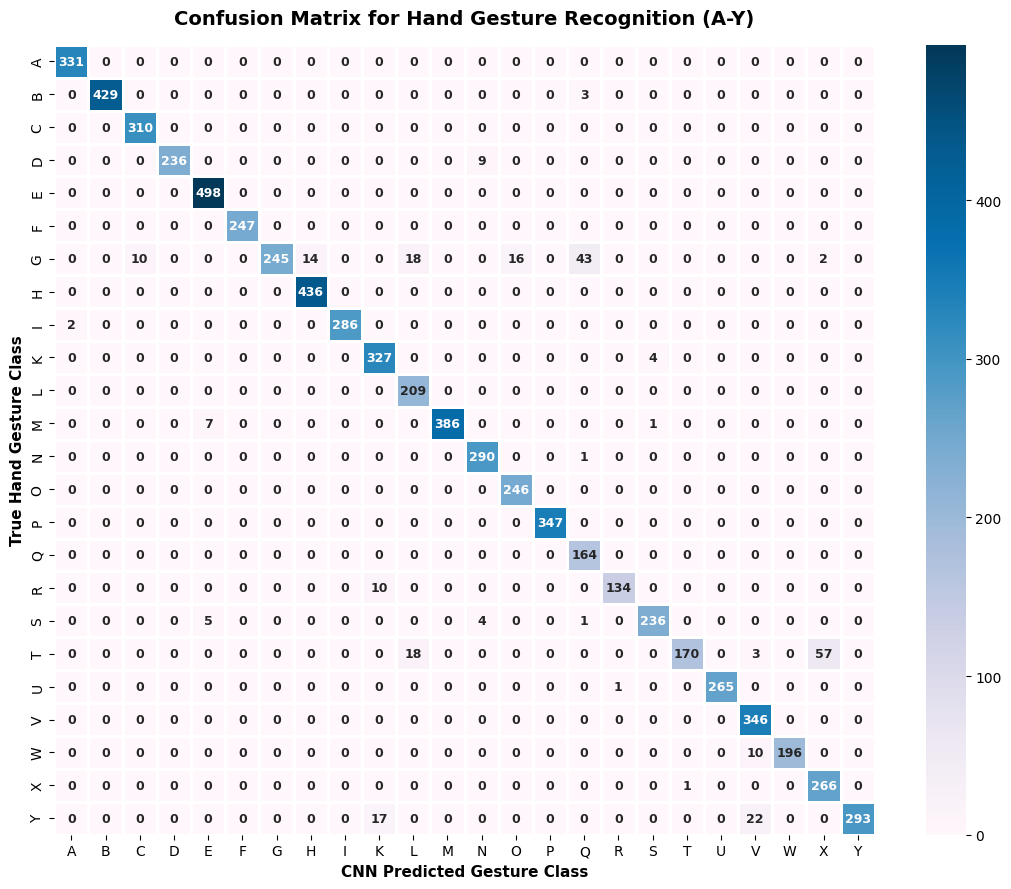

In [11]:
# Compute confusion matrix across all 24 gesture classes
cm = confusion_matrix(y_test_idx, y_pred_idx)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='PuBu',
    xticklabels=gesture_classes,
    yticklabels=gesture_classes,
    cbar=True,
    linewidths=0.8,
    linecolor='white',
    annot_kws={"size": 9, "weight": "bold"}
)

plt.title("Confusion Matrix for Hand Gesture Recognition (A-Y)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("True Hand Gesture Class", fontsize=11, fontweight='bold')
plt.xlabel("CNN Predicted Gesture Class", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## **Conclusion**
In this practical, a Convolutional Neural Network (CNN) for multi-class Hand Gesture Recognition was successfully constructed, trained, and evaluated using Python and TensorFlow/Keras on the Sign Language MNIST dataset.

Hand gesture image matrices were downloaded via kagglehub, preprocessed, normalized to $[0.0, 1.0]$, and one-hot encoded.

A deep 3-block CNN model with batch normalization and dropout was trained and evaluated on unseen gesture images.